#03 学术人物画廊

该笔记本使用合成但结构化的数据演示了提示中的所有 19 种绘图类型。

## 环境和风格基线

全局样式、种子和输出约定在这里统一，以确保发布样式的一致性。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
FIG_DIR = ROOT / 'figures' / '03_figure_vs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_show(name: str):
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'saved: {out}')

print('figure dir:', FIG_DIR)

figure dir: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs


## 综合数据准备

本节准备 19 个图所需的所有数据集：方法表、趋势曲线、分类分数、矩阵、长尾数据和构面场景。

In [2]:
# Core method comparison table
methods_short = ['Baseline', 'Method-A', 'Method-B', 'Method-C']
methods_long = [
    'Baseline Transformer (large)',
    'SubspaceNet + EKF + Calibration',
    'Diffusion Prior + Sparse Decoder',
    'Hybrid Physics-Informed Ensemble'
]

perf_df = pd.DataFrame({
    'method_short': methods_short,
    'method_long': methods_long,
    'accuracy': [84.1, 87.3, 88.6, 89.0],
    'f1': [0.821, 0.856, 0.869, 0.875],
    'latency_ms': [10.2, 14.8, 20.5, 28.2],
    'memory_mb': [620, 790, 930, 1210],
    'params_m': [12, 24, 38, 55],
    'acc_std': [0.5, 0.4, 0.3, 0.3],
    'f1_std': [0.012, 0.010, 0.009, 0.008]
})

# Stacked decomposition (time budget)
time_df = pd.DataFrame({
    'method': methods_short,
    'load_ms': [1.2, 1.4, 1.8, 2.1],
    'infer_ms': [7.4, 10.5, 14.9, 20.2],
    'post_ms': [1.6, 2.9, 3.8, 5.9]
})

# Training curves with confidence bands
epochs = np.arange(1, 101)
base_curve = 1.2 * np.exp(-epochs / 28.0) + 0.08
loss_mean = {
    'Baseline': base_curve + 0.05,
    'Method-A': base_curve * 0.90,
    'Method-B': base_curve * 0.84,
}
loss_std = {
    'Baseline': 0.08 * np.exp(-epochs / 35) + 0.012,
    'Method-A': 0.07 * np.exp(-epochs / 35) + 0.010,
    'Method-B': 0.06 * np.exp(-epochs / 35) + 0.009,
}

# Near-converged curves for inset demonstration
acc_base = 0.70 + 0.26 * (1 - np.exp(-epochs / 18.0))
acc_a = acc_base + 0.005 * (1 - np.exp(-epochs / 35.0))
acc_b = acc_base + 0.009 * (1 - np.exp(-epochs / 35.0))

# Scatter-fit data
x_noise = np.linspace(0, 20, 80)
y_error = 0.5 + 0.06 * x_noise + 0.004 * x_noise**2 + np.random.normal(0, 0.35, size=x_noise.size)

# ROC / PR synthetic scores
n_bal = 800
y_true_bal = np.r_[np.zeros(n_bal//2), np.ones(n_bal//2)]
score_bal = np.r_[np.random.normal(0.35, 0.18, n_bal//2), np.random.normal(0.68, 0.18, n_bal//2)]
score_bal = np.clip(score_bal, 0, 1)

n_imb = 4000
pos = int(0.08 * n_imb)
y_true_imb = np.r_[np.ones(pos), np.zeros(n_imb - pos)]
score_imb = np.r_[np.random.normal(0.70, 0.16, pos), np.random.normal(0.30, 0.16, n_imb-pos)]
score_imb = np.clip(score_imb, 0, 1)

# Heatmap matrix (model x task)
heat_models = ['Base', 'A', 'B', 'C', 'Ours']
heat_tasks = ['Task1', 'Task2', 'Task3', 'Task4', 'Task5', 'Task6']
heat_data = np.array([
    [72, 68, 74, 70, 66, 69],
    [78, 73, 81, 76, 72, 75],
    [80, 76, 83, 79, 75, 77],
    [81, 78, 84, 80, 77, 79],
    [84, 81, 87, 83, 80, 82],
], dtype=float)

# Pred vs true scatter
y_true_reg = np.linspace(5, 95, 120)
y_pred_reg = y_true_reg + np.random.normal(0, 6.0, size=y_true_reg.shape)

# Bubble chart
a = perf_df['accuracy'].values
l = perf_df['latency_ms'].values
p = perf_df['params_m'].values

# Violin / box distribution
dist_data = {
    'Baseline': np.random.normal(4.0, 0.9, 180),
    'Method-A': np.r_[np.random.normal(3.0, 0.45, 120), np.random.normal(4.2, 0.35, 60)],
    'Method-B': np.random.normal(2.6, 0.55, 180),
    'Method-C': np.random.normal(2.3, 0.48, 180),
}

# Donut composition
error_types = ['Boundary miss', 'Confusion', 'False trigger', 'Localization drift', 'Other']
error_counts = np.array([28, 22, 14, 25, 11])

# Dual-axis data
epoch2 = np.arange(1, 31)
acc_dual = 78 + 10 * (1 - np.exp(-epoch2 / 10))
mem_dual = 580 + 11 * epoch2

# Bar-line combo (long-tail)
classes = [f'C{i}' for i in range(1, 13)]
sample_counts = np.array([1200, 980, 760, 540, 420, 300, 220, 170, 130, 95, 70, 45])
class_acc = np.array([92, 91, 90, 88, 87, 85, 84, 82, 80, 77, 74, 70])

# Facet grid style data
conditions = ['SNR=-5dB', 'SNR=0dB', 'SNR=5dB', 'SNR=10dB']
models = ['Baseline', 'Method-A', 'Method-B']
facet_records = []
for cond_i, cond in enumerate(conditions):
    x = np.arange(1, 16)
    for m_i, m in enumerate(models):
        base = 30 + cond_i * 12 + m_i * 5
        y = base + 12 * np.log1p(x) + np.random.normal(0, 1.2, size=x.size)
        for xi, yi in zip(x, y):
            facet_records.append((cond, m, xi, yi))
facet_df = pd.DataFrame(facet_records, columns=['condition', 'model', 'step', 'score'])

print('Synthetic dataset prepared.')

Synthetic dataset prepared.


## 1) 分组垂直条形图

标准 SOTA 与方法指标和可选误差线的比较。

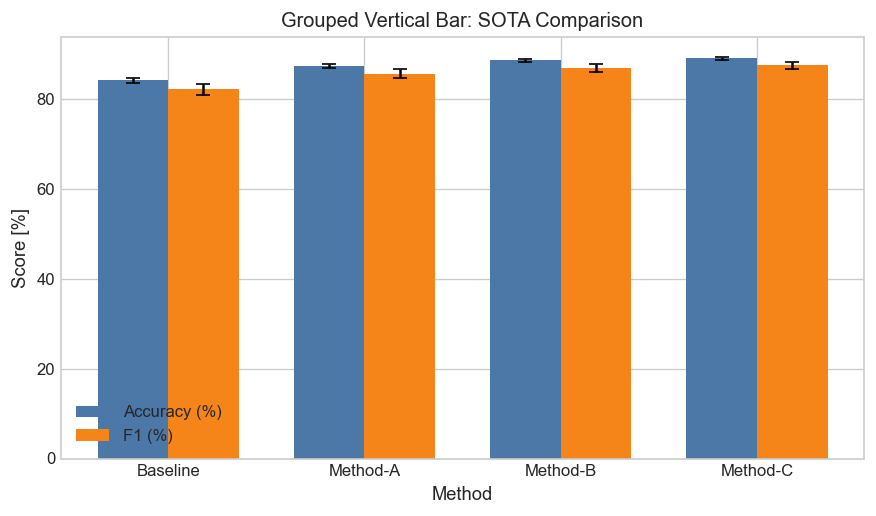

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\01_grouped_vertical_bar.png


In [3]:
x = np.arange(len(methods_short))
width = 0.36

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.bar(x - width/2, perf_df['accuracy'], width, yerr=perf_df['acc_std'], capsize=4, label='Accuracy (%)', color='#4C78A8')
ax.bar(x + width/2, perf_df['f1'] * 100, width, yerr=perf_df['f1_std']*100, capsize=4, label='F1 (%)', color='#F58518')
ax.set_xticks(x)
ax.set_xticklabels(methods_short)
ax.set_ylabel('Score [%]')
ax.set_xlabel('Method')
ax.set_title('Grouped Vertical Bar: SOTA Comparison')
ax.legend(frameon=False)
save_show('01_grouped_vertical_bar.png')

## 2) 水平条形图

最适合长标签或多种方法，与拥挤的 x 轴标签相比，提高了可读性。

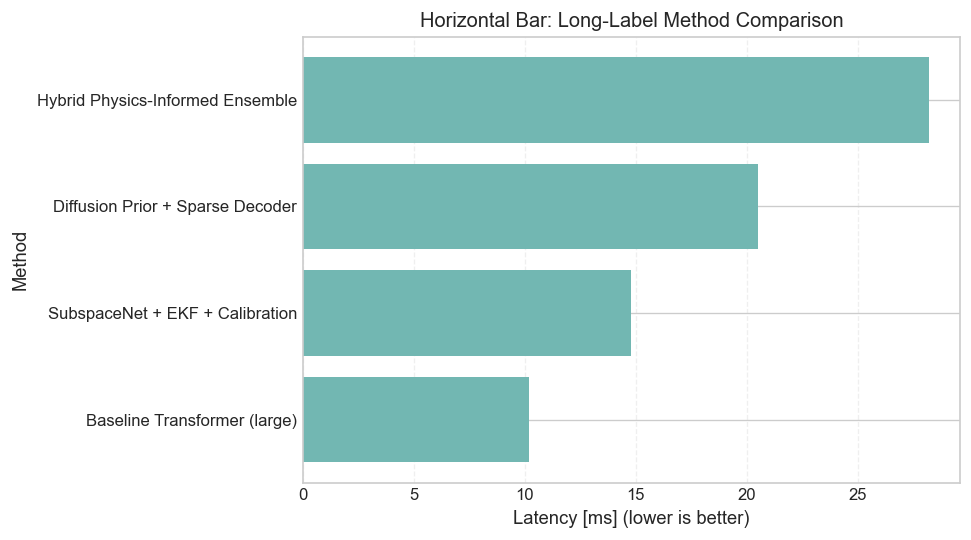

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\02_horizontal_bar.png


In [4]:
order = perf_df.sort_values('latency_ms', ascending=True)
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.barh(order['method_long'], order['latency_ms'], color='#72B7B2')
ax.set_xlabel('Latency [ms] (lower is better)')
ax.set_ylabel('Method')
ax.set_title('Horizontal Bar: Long-Label Method Comparison')
ax.grid(axis='x', linestyle='--', alpha=0.3)
save_show('02_horizontal_bar.png')

## 3) 帕累托前沿图

用于呈现相互冲突的指标（例如准确性和延迟）之间的权衡。

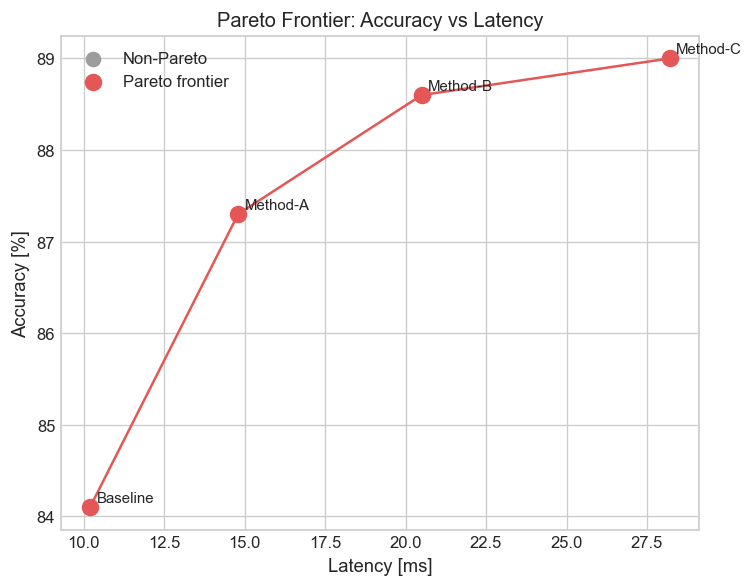

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\03_pareto_frontier.png


In [5]:
x = perf_df['latency_ms'].to_numpy()
y = perf_df['accuracy'].to_numpy()
labels = perf_df['method_short'].to_numpy()

is_pareto = np.ones(len(x), dtype=bool)
for i in range(len(x)):
    for j in range(len(x)):
        if i == j:
            continue
        if (x[j] <= x[i] and y[j] >= y[i]) and (x[j] < x[i] or y[j] > y[i]):
            is_pareto[i] = False
            break

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.scatter(x[~is_pareto], y[~is_pareto], s=70, color='#9D9D9D', label='Non-Pareto')
ax.scatter(x[is_pareto], y[is_pareto], s=90, color='#E45756', label='Pareto frontier')

pf = np.argsort(x[is_pareto])
ax.plot(x[is_pareto][pf], y[is_pareto][pf], color='#E45756', linewidth=1.5)

for xi, yi, t in zip(x, y, labels):
    ax.annotate(t, (xi, yi), xytext=(4, 3), textcoords='offset points', fontsize=9)

ax.set_xlabel('Latency [ms]')
ax.set_ylabel('Accuracy [%]')
ax.set_title('Pareto Frontier: Accuracy vs Latency')
ax.legend(frameon=False)
save_show('03_pareto_frontier.png')

## 4) 雷达图

对于统一归一化后的多维度能力比较很有用。

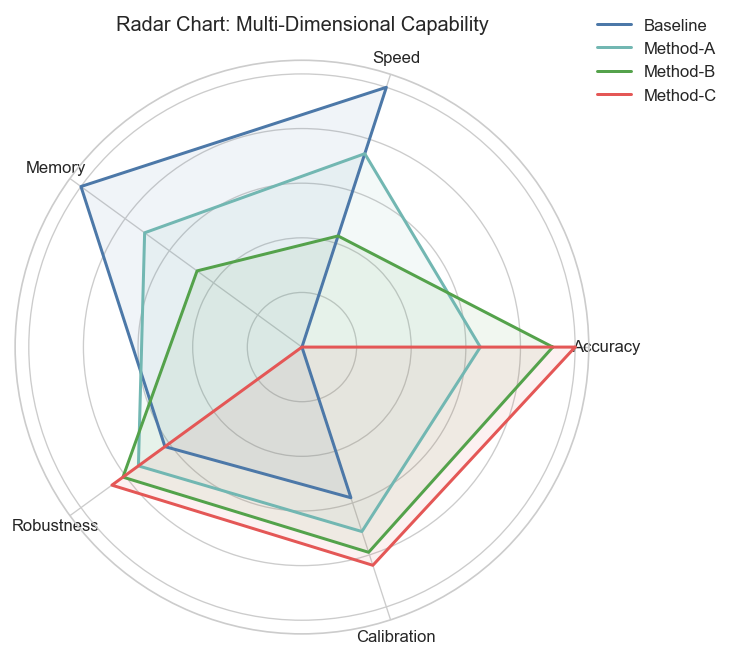

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\04_radar_chart.png


In [6]:
radar_dims = ['Accuracy', 'Speed', 'Memory', 'Robustness', 'Calibration']
# normalize to [0,1], bigger better
acc_n = (perf_df['accuracy'] - perf_df['accuracy'].min()) / (perf_df['accuracy'].max() - perf_df['accuracy'].min())
speed_n = 1 - (perf_df['latency_ms'] - perf_df['latency_ms'].min()) / (perf_df['latency_ms'].max() - perf_df['latency_ms'].min())
mem_n = 1 - (perf_df['memory_mb'] - perf_df['memory_mb'].min()) / (perf_df['memory_mb'].max() - perf_df['memory_mb'].min())
rob_n = np.array([0.62, 0.74, 0.81, 0.86])
cal_n = np.array([0.58, 0.71, 0.79, 0.84])

radar_vals = np.vstack([acc_n, speed_n, mem_n, rob_n, cal_n]).T
angles = np.linspace(0, 2*np.pi, len(radar_dims), endpoint=False)
angles = np.r_[angles, angles[0]]

fig = plt.figure(figsize=(6.2, 6.2))
ax = plt.subplot(111, polar=True)
colors = ['#4C78A8', '#72B7B2', '#54A24B', '#E45756']
for i, row in enumerate(radar_vals):
    vals = np.r_[row, row[0]]
    ax.plot(angles, vals, linewidth=1.8, label=methods_short[i], color=colors[i])
    ax.fill(angles, vals, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_dims)
ax.set_yticklabels([])
ax.set_title('Radar Chart: Multi-Dimensional Capability', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.10), frameon=False)
save_show('04_radar_chart.png')

## 5) 堆积条形图

用于组件分解，例如运行时分解为加载/推理/后处理。

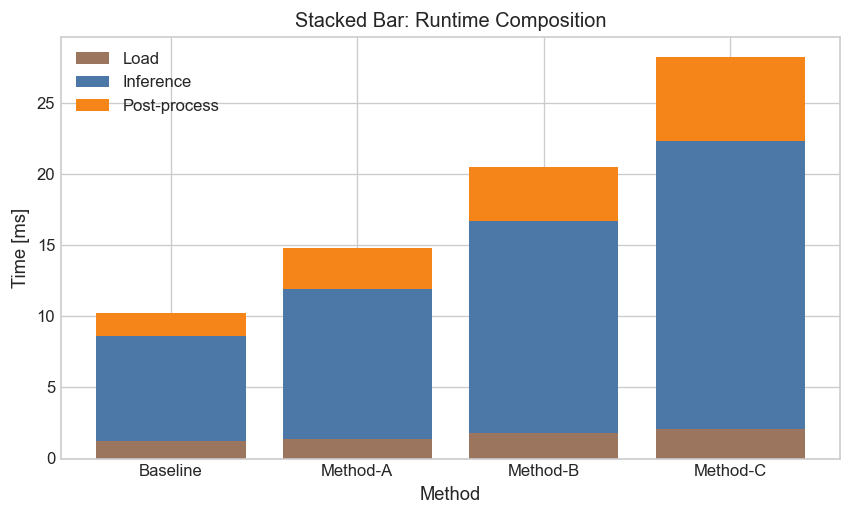

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\05_stacked_bar.png


In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.bar(time_df['method'], time_df['load_ms'], label='Load', color='#9C755F')
ax.bar(time_df['method'], time_df['infer_ms'], bottom=time_df['load_ms'], label='Inference', color='#4C78A8')
ax.bar(time_df['method'], time_df['post_ms'], bottom=time_df['load_ms'] + time_df['infer_ms'], label='Post-process', color='#F58518')
ax.set_ylabel('Time [ms]')
ax.set_xlabel('Method')
ax.set_title('Stacked Bar: Runtime Composition')
ax.legend(frameon=False)
save_show('05_stacked_bar.png')

## 6) 带置信区间的折线图

显示趋势和不确定性，适合重复运行的训练曲线。

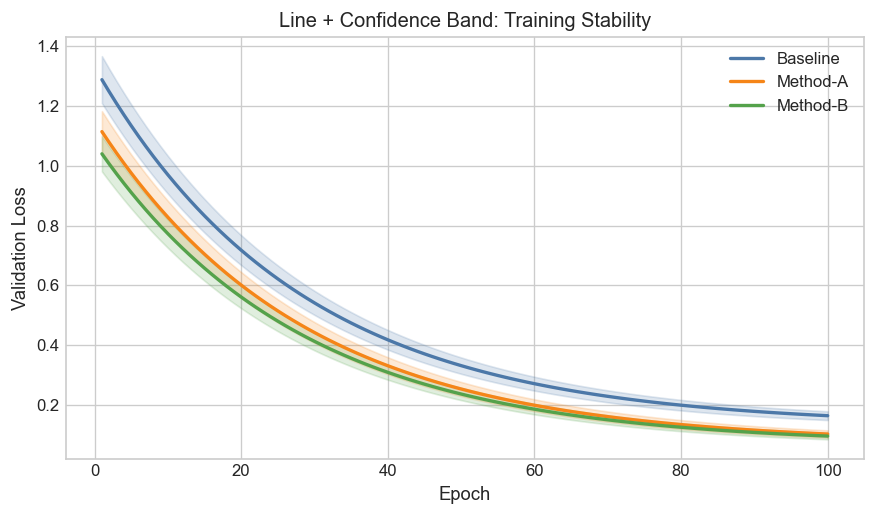

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\06_line_confidence.png


In [8]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
palette = {'Baseline':'#4C78A8', 'Method-A':'#F58518', 'Method-B':'#54A24B'}
for k in ['Baseline', 'Method-A', 'Method-B']:
    m = loss_mean[k]
    s = loss_std[k]
    ci = 1.96 * s / np.sqrt(5)
    ax.plot(epochs, m, label=k, color=palette[k], linewidth=2)
    ax.fill_between(epochs, m-ci, m+ci, color=palette[k], alpha=0.18)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Line + Confidence Band: Training Stability')
ax.legend(frameon=False)
save_show('06_line_confidence.png')

## 7) 插图缩放折线图

添加缩放区域以显示方法之间微小的后期间隙。

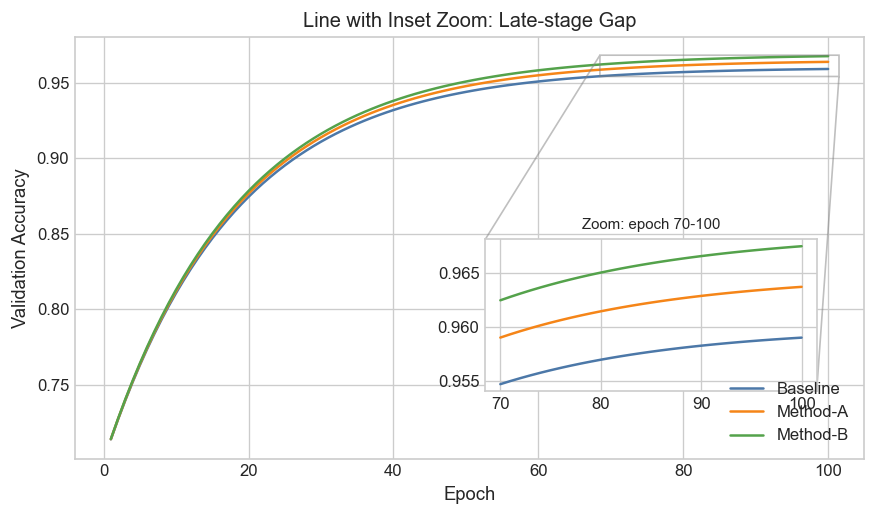

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\07_inset_zoom_line.png


In [9]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(epochs, acc_base, label='Baseline', color='#4C78A8')
ax.plot(epochs, acc_a, label='Method-A', color='#F58518')
ax.plot(epochs, acc_b, label='Method-B', color='#54A24B')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Line with Inset Zoom: Late-stage Gap')
ax.legend(frameon=False, loc='lower right')

axins = ax.inset_axes([0.52, 0.16, 0.42, 0.36])
mask = (epochs >= 70)
axins.plot(epochs[mask], acc_base[mask], color='#4C78A8')
axins.plot(epochs[mask], acc_a[mask], color='#F58518')
axins.plot(epochs[mask], acc_b[mask], color='#54A24B')
axins.set_title('Zoom: epoch 70-100', fontsize=9)
ax.indicate_inset_zoom(axins, edgecolor='gray')
save_show('07_inset_zoom_line.png')

## 8) 使用拟合曲线进行散点

捕获全局变量关系并提供合适的趋势进行解释。

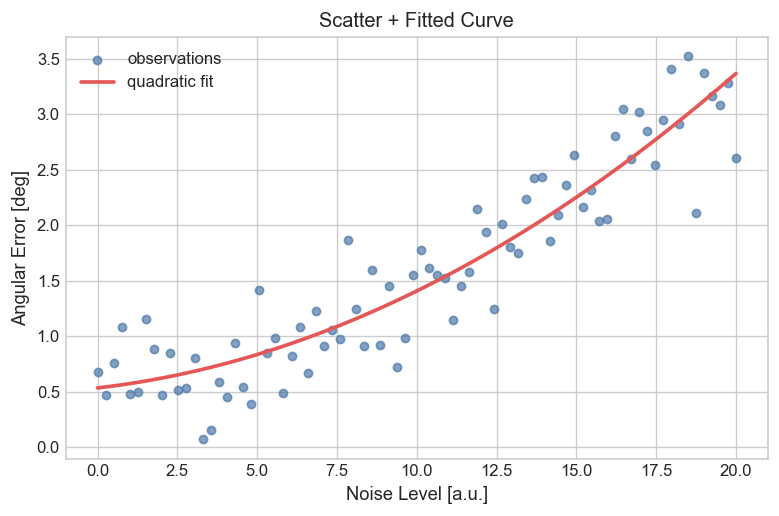

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\08_scatter_fit.png


In [10]:
coef = np.polyfit(x_noise, y_error, deg=2)
poly = np.poly1d(coef)
x_fit = np.linspace(x_noise.min(), x_noise.max(), 200)

fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.scatter(x_noise, y_error, s=24, alpha=0.7, color='#4C78A8', label='observations')
ax.plot(x_fit, poly(x_fit), color='#E45756', linewidth=2.2, label='quadratic fit')
ax.set_xlabel('Noise Level [a.u.]')
ax.set_ylabel('Angular Error [deg]')
ax.set_title('Scatter + Fitted Curve')
ax.legend(frameon=False)
save_show('08_scatter_fit.png')

## 9) ROC 曲线

相对平衡类别下的二元分类标准。

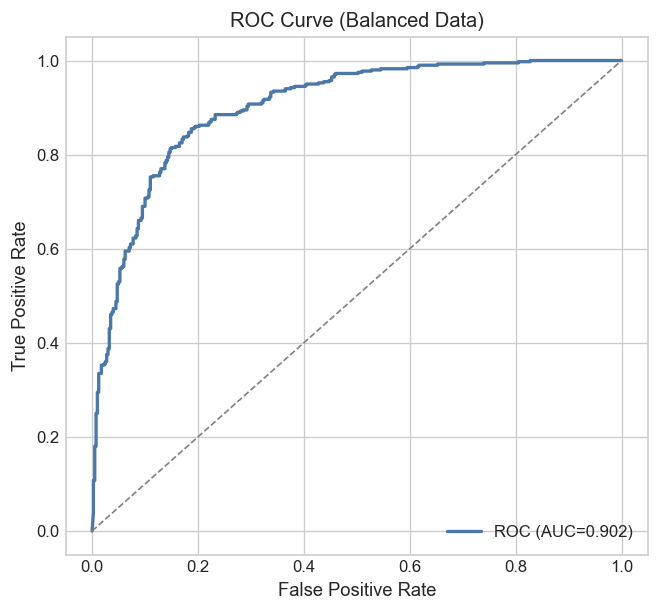

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\09_roc_curve.png


In [11]:
fpr, tpr, _ = roc_curve(y_true_bal, score_bal)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot(fpr, tpr, color='#4C78A8', linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Balanced Data)')
ax.legend(frameon=False, loc='lower right')
save_show('09_roc_curve.png')

## 10) 精确率-召回率曲线

在精度行为至关重要的不平衡环境中是首选。

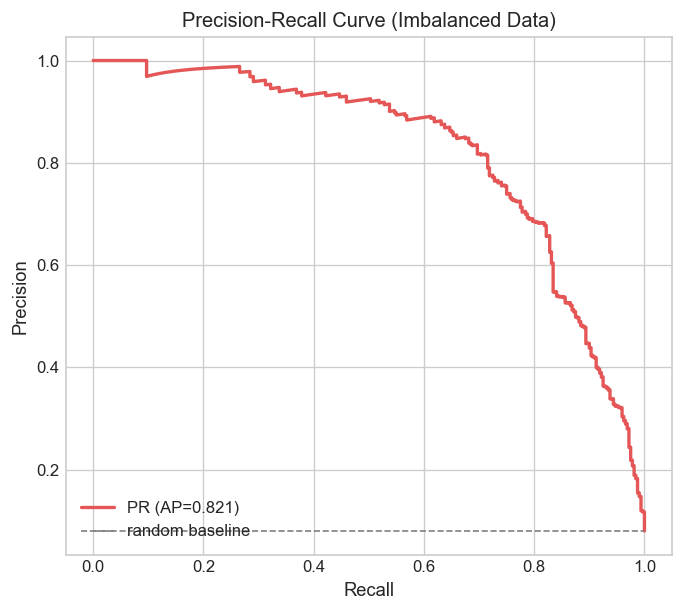

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\10_pr_curve.png


In [12]:
prec, rec, _ = precision_recall_curve(y_true_imb, score_imb)
ap = average_precision_score(y_true_imb, score_imb)
base_rate = y_true_imb.mean()

fig, ax = plt.subplots(figsize=(5.8, 5.2))
ax.plot(rec, prec, color='#E45756', linewidth=2, label=f'PR (AP={ap:.3f})')
ax.hlines(base_rate, 0, 1, linestyles='--', colors='gray', linewidth=1, label='random baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Imbalanced Data)')
ax.legend(frameon=False, loc='lower left')
save_show('10_pr_curve.png')

## 11) 热图

用于模型任务或特征相关性比较的矩阵式概述。

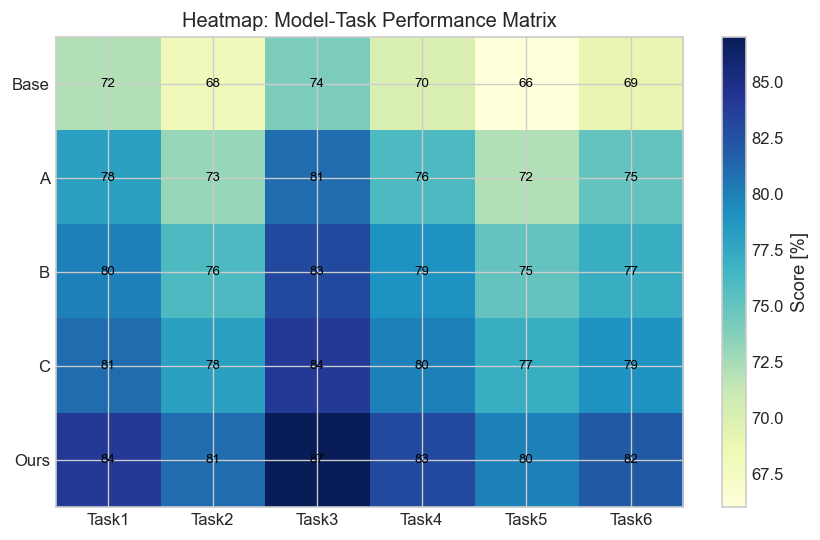

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\11_heatmap_matrix.png


In [13]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
im = ax.imshow(heat_data, cmap='YlGnBu', aspect='auto')
ax.set_xticks(np.arange(len(heat_tasks)))
ax.set_xticklabels(heat_tasks)
ax.set_yticks(np.arange(len(heat_models)))
ax.set_yticklabels(heat_models)
ax.set_title('Heatmap: Model-Task Performance Matrix')

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, f'{heat_data[i, j]:.0f}', ha='center', va='center', color='black', fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Score [%]')
save_show('11_heatmap_matrix.png')

## 12) 预测与真实散点图

使用对角参考线评估校准和残余扩散。

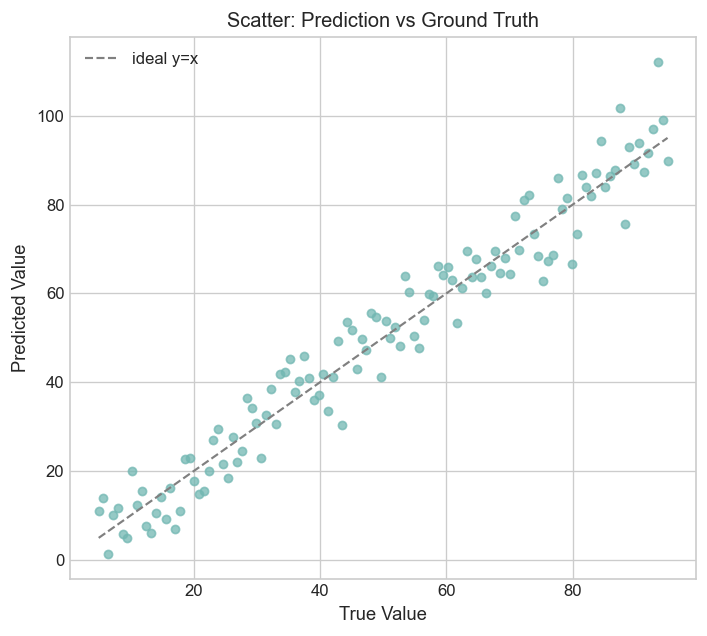

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\12_scatter_pred_true.png


In [14]:
fig, ax = plt.subplots(figsize=(6.0, 5.4))
ax.scatter(y_true_reg, y_pred_reg, s=24, alpha=0.75, color='#72B7B2')
mn, mx = y_true_reg.min(), y_true_reg.max()
ax.plot([mn, mx], [mn, mx], '--', color='gray', linewidth=1.3, label='ideal y=x')
ax.set_xlabel('True Value')
ax.set_ylabel('Predicted Value')
ax.set_title('Scatter: Prediction vs Ground Truth')
ax.legend(frameon=False)
save_show('12_scatter_pred_true.png')

## 13) 气泡图

通过标记大小添加第三个变量（例如参数计数）。

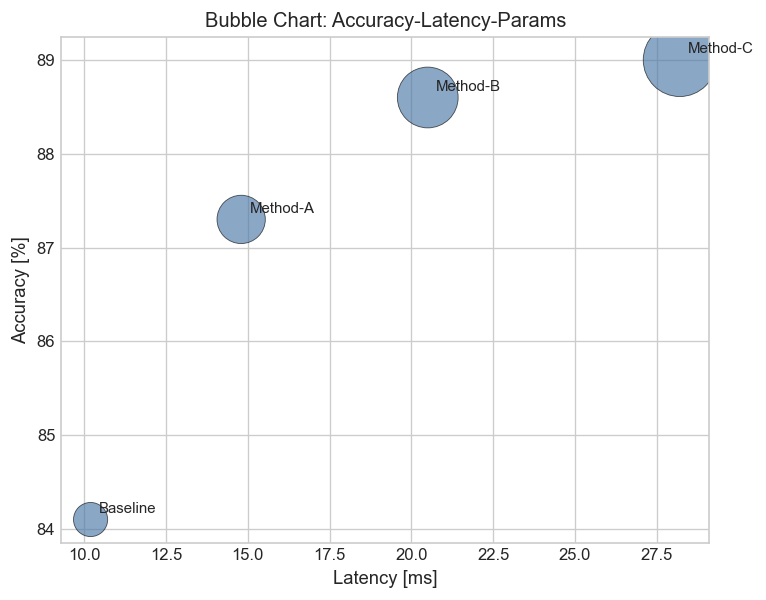

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\13_bubble_chart.png


In [15]:
sizes = 35 * p
fig, ax = plt.subplots(figsize=(6.5, 5.1))
ax.scatter(l, a, s=sizes, alpha=0.65, color='#4C78A8', edgecolor='black', linewidth=0.5)
for xi, yi, name in zip(l, a, methods_short):
    ax.annotate(name, (xi, yi), textcoords='offset points', xytext=(5, 4), fontsize=9)
ax.set_xlabel('Latency [ms]')
ax.set_ylabel('Accuracy [%]')
ax.set_title('Bubble Chart: Accuracy-Latency-Params')
save_show('13_bubble_chart.png')

## 14) 小提琴情节

显示完整的分布密度形状，包括偏斜和多模态。

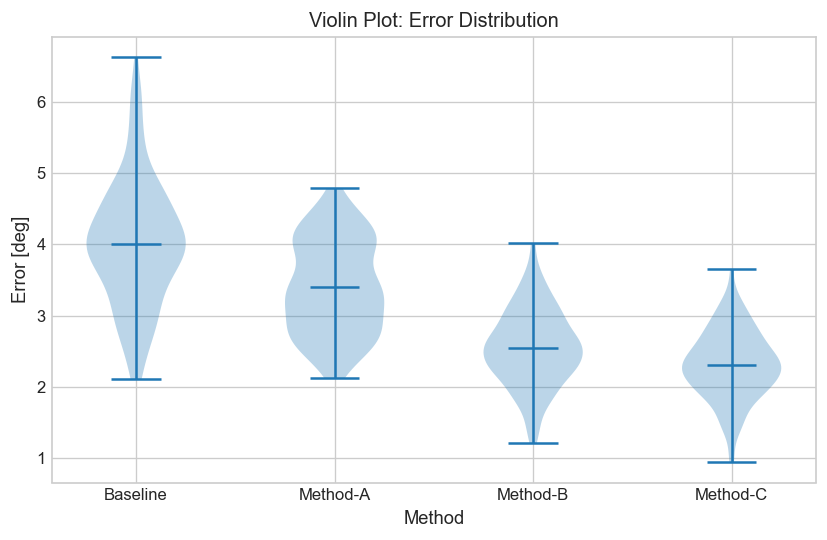

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\14_violin_plot.png


In [16]:
vals = [dist_data[k] for k in methods_short]
fig, ax = plt.subplots(figsize=(7.0, 4.6))
parts = ax.violinplot(vals, showmeans=True, showextrema=True)
ax.set_xticks(np.arange(1, len(methods_short)+1))
ax.set_xticklabels(methods_short)
ax.set_ylabel('Error [deg]')
ax.set_xlabel('Method')
ax.set_title('Violin Plot: Error Distribution')
save_show('14_violin_plot.png')

## 15) 箱线图

使用中位数、四分位数和异常值进行紧凑稳健的汇总。

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26364\680667371.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, labels=methods_short, showfliers=True)


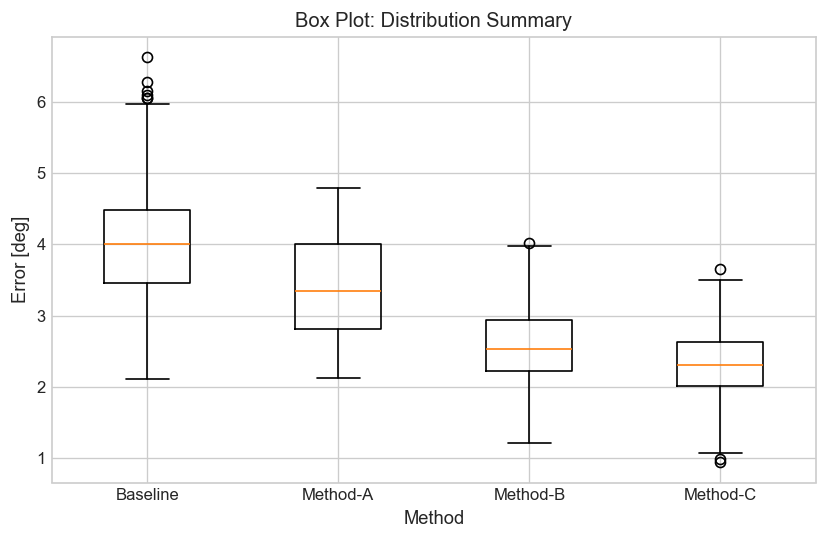

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\15_box_plot.png


In [17]:
vals = [dist_data[k] for k in methods_short]
fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.boxplot(vals, labels=methods_short, showfliers=True)
ax.set_ylabel('Error [deg]')
ax.set_xlabel('Method')
ax.set_title('Box Plot: Distribution Summary')
save_show('15_box_plot.png')

## 16) 圆环图

类别组成可视化，通常用于错误类型细分。

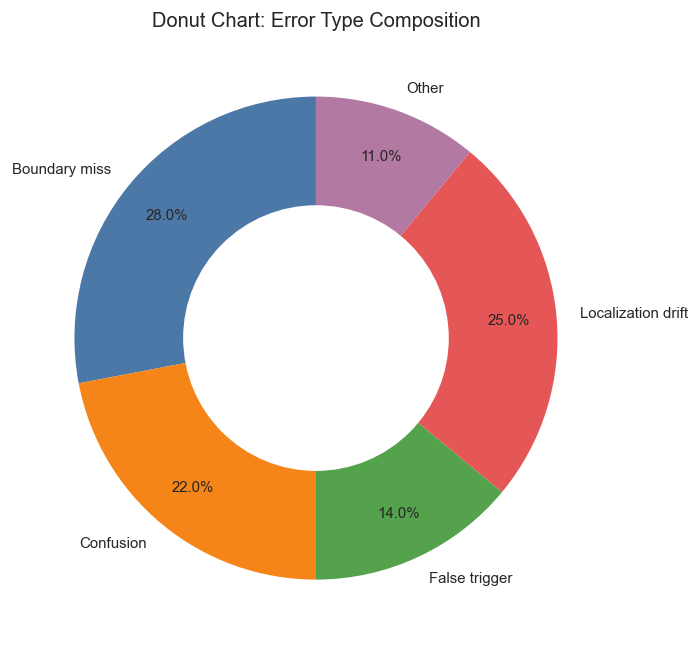

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\16_donut_chart.png


In [18]:
fig, ax = plt.subplots(figsize=(6.0, 6.0))
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#B279A2']
wedges, texts, autotexts = ax.pie(
    error_counts,
    labels=error_types,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    textprops={'fontsize':9}
)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre_circle)
ax.set_title('Donut Chart: Error Type Composition')
save_show('16_donut_chart.png')

## 17) 双 Y 轴图

将两个具有不同单位的变量组合在一个共享的 x 轴上。

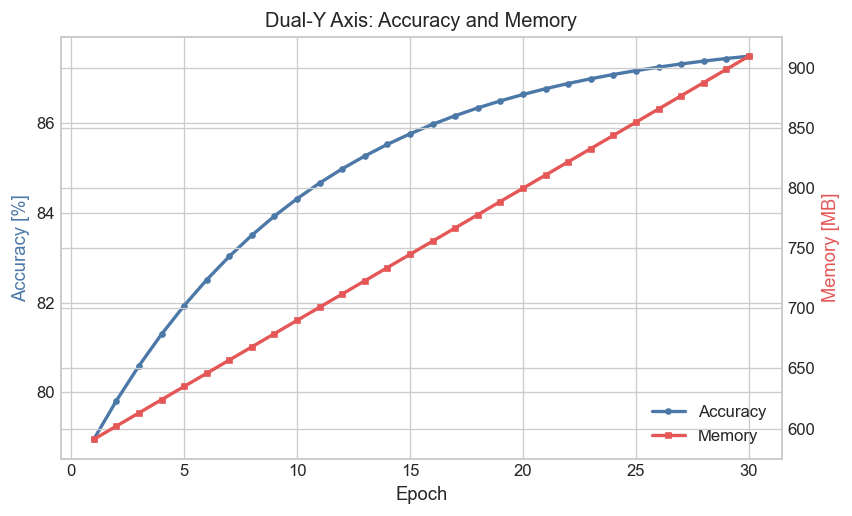

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\17_dual_y_axis.png


In [19]:
fig, ax1 = plt.subplots(figsize=(7.2, 4.4))
ax2 = ax1.twinx()

ax1.plot(epoch2, acc_dual, color='#4C78A8', linewidth=2, marker='o', markersize=3, label='Accuracy')
ax2.plot(epoch2, mem_dual, color='#E45756', linewidth=2, marker='s', markersize=3, label='Memory')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy [%]', color='#4C78A8')
ax2.set_ylabel('Memory [MB]', color='#E45756')
ax1.set_title('Dual-Y Axis: Accuracy and Memory')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='lower right', frameon=False)
save_show('17_dual_y_axis.png')

## 18) 条形线组合图

背景数量+前景表现，常见于长尾分析。

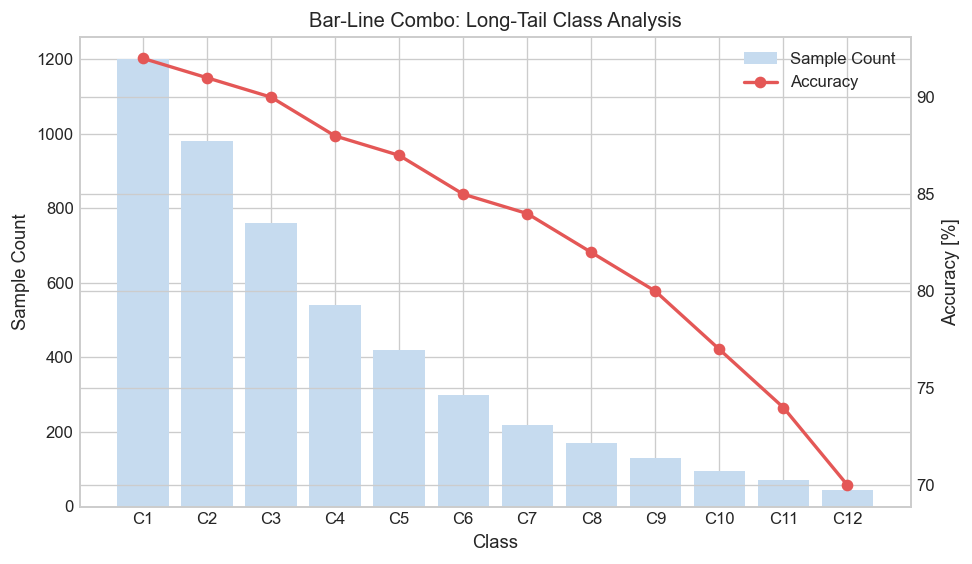

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\18_bar_line_combo.png


In [20]:
fig, ax1 = plt.subplots(figsize=(8.2, 4.8))
ax2 = ax1.twinx()

ax1.bar(classes, sample_counts, color='#C6DBEF', label='Sample Count')
ax2.plot(classes, class_acc, color='#E45756', marker='o', linewidth=2, label='Accuracy')

ax1.set_xlabel('Class')
ax1.set_ylabel('Sample Count')
ax2.set_ylabel('Accuracy [%]')
ax1.set_title('Bar-Line Combo: Long-Tail Class Analysis')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', frameon=False)
save_show('18_bar_line_combo.png')

## 19) 面网格

为了清晰起见，将多条件比较拆分为对齐的小倍数。

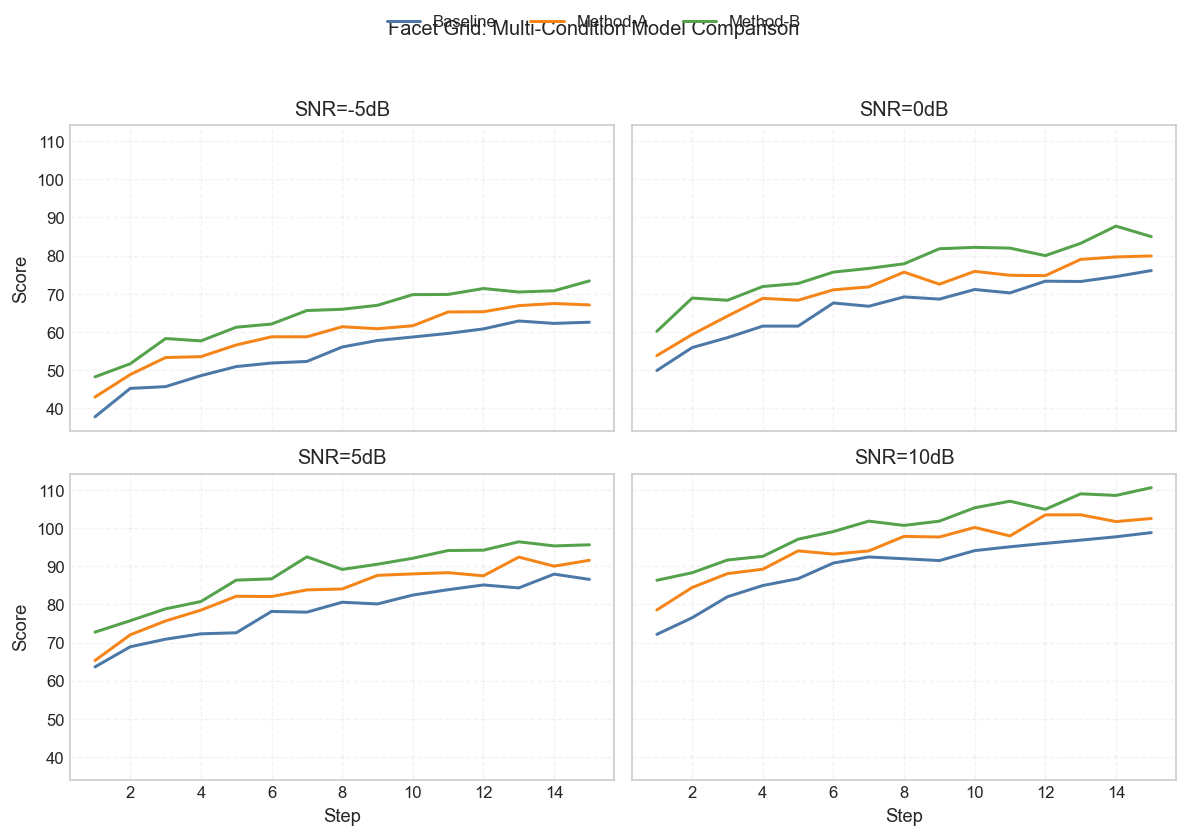

saved: D:\LiLei\Python_projects\SubspaceNet_Update\figures\03_figure_vs\19_facet_grid.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.ravel()
colors = {'Baseline':'#4C78A8', 'Method-A':'#F58518', 'Method-B':'#54A24B'}

for idx, cond in enumerate(conditions):
    ax = axes[idx]
    sub = facet_df[facet_df['condition'] == cond]
    for m in models:
        d = sub[sub['model'] == m]
        ax.plot(d['step'], d['score'], label=m, color=colors[m], linewidth=1.8)
    ax.set_title(cond)
    ax.grid(alpha=0.25, linestyle='--')

axes[2].set_xlabel('Step')
axes[3].set_xlabel('Step')
axes[0].set_ylabel('Score')
axes[2].set_ylabel('Score')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False)
fig.suptitle('Facet Grid: Multi-Condition Model Comparison', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / '19_facet_grid.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"saved: {FIG_DIR / '19_facet_grid.png'}")

## 出口检查

打印所有生成的图形文件以确认完整的输出生成。

In [22]:
files = sorted(FIG_DIR.glob('*.png'))
print(f'total png files: {len(files)}')
for f in files:
    print('-', f.name)

total png files: 19
- 01_grouped_vertical_bar.png
- 02_horizontal_bar.png
- 03_pareto_frontier.png
- 04_radar_chart.png
- 05_stacked_bar.png
- 06_line_confidence.png
- 07_inset_zoom_line.png
- 08_scatter_fit.png
- 09_roc_curve.png
- 10_pr_curve.png
- 11_heatmap_matrix.png
- 12_scatter_pred_true.png
- 13_bubble_chart.png
- 14_violin_plot.png
- 15_box_plot.png
- 16_donut_chart.png
- 17_dual_y_axis.png
- 18_bar_line_combo.png
- 19_facet_grid.png
